In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime, timedelta
import seaborn as sns

In [2]:
ledger_df=pd.read_csv("ledger.csv")
gateway_df=pd.read_csv("gateway_export.csv")
merchants_df=pd.read_csv("merchants.csv")
ledger_ids=set(ledger_df['transaction_id'])
gateway_ids=set(gateway_df['transaction_id'])

## GMV- Gross Merchandise Value
successful_txns=ledger_df[ledger_df['status']=='captured']
total_gmv=successful_txns['amount_inr'].sum()

## Overall Success Rate
total_ledger_txns=len(ledger_df)
success_count=len(successful_txns)
success_rate=(success_count/total_ledger_txns)*100

##Reconciliation Match Mate
common_ids=ledger_ids.intersection(gateway_ids)
ledger_common=ledger_df[ledger_df['transaction_id'].isin(common_ids)]
gateway_common=gateway_df[gateway_df['transaction_id'].isin(common_ids)]
merged_df=ledger_common.merge(gateway_common[['transaction_id','amount_inr','status']],
on='transaction_id',
suffixes=('_ledg','_gate'))
desired_columns=['transaction_id', 'user_id', 'merchant_id', 'transaction_time', 'amount_inr_ledg', 'amount_inr_gate', 'status_ledg', 'status_gate', 'payment_method', 'risk_score']
merged_df = merged_df[desired_columns]

perfect_matches=merged_df[
    (merged_df['amount_inr_ledg']==merged_df['amount_inr_gate'])&
    (merged_df['status_ledg']==merged_df['status_gate'])
    ]
perfect_match_count=len(perfect_matches)
match_rate=(perfect_match_count/total_ledger_txns)*100

##Chargeback Ratio
chargeback_count=len(ledger_df[ledger_df.status=='chargeback'])
chargeback_ratio=(chargeback_count/total_ledger_txns)*100

##Scorecard display for the Headline layer
print("==================================================")
print("             HEADLINE SCORECARDS                  ")
print("==================================================")
print(f"Total GMV (INR):             ₹{total_gmv:,.2f}")
print(f"Overall Success Rate:        {success_rate:.2f}%")
print(f"Reconciliation Match Rate:   {match_rate:.2f}%")
print(f"Platform Chargeback Ratio:   {chargeback_ratio:.2f}%")
print("==================================================")

             HEADLINE SCORECARDS                  
Total GMV (INR):             ₹290,382.00
Overall Success Rate:        85.56%
Reconciliation Match Rate:   90.49%
Platform Chargeback Ratio:   5.12%


Headline scorecards successfully saved as 'headline_scorecards.png'


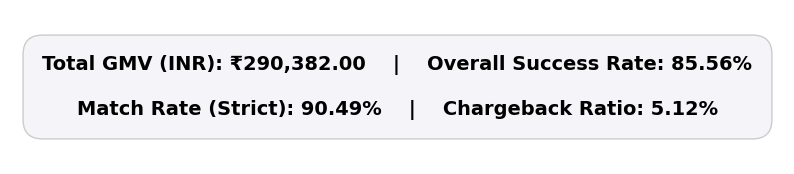

In [3]:
##Image output for the Headline Scorecard
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')

scorecard_text = (
    f"Total GMV (INR): ₹{total_gmv:,.2f}    |    "
    f"Overall Success Rate: {success_rate:.2f}%\n\n"
    f"Match Rate (Strict): {match_rate:.2f}%    |    "
    f"Chargeback Ratio: {chargeback_ratio:.2f}%"
)

ax.text(0.5, 0.5, scorecard_text,
        fontsize=14,
        ha='center',
        va='center',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=1', facecolor='#f4f4f9', edgecolor='#cccccc'))

plt.savefig('headline_scorecards.png', bbox_inches='tight', dpi=300)
print("Headline scorecards successfully saved as 'headline_scorecards.png'")

plt.show()

In [4]:
##Data Preperation for Trends, Breakdown and Details Layer
ledger_df['transaction_time'] = pd.to_datetime(ledger_df['transaction_time'])
ledger_df['transaction_date']=ledger_df['transaction_time'].dt.date
master_df=ledger_df.merge(merchants_df, on='merchant_id', how='left')
successful_gmv_df=master_df[master_df['status'] == 'captured']


Trends Layer image successfully saved as 'trend_layer_chart.png'


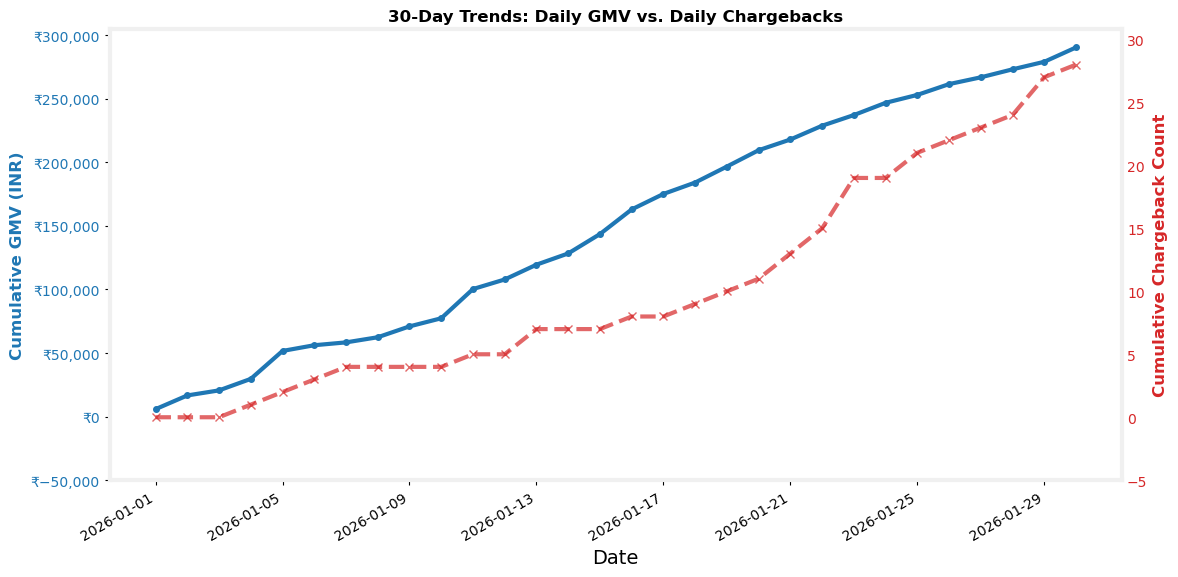

In [5]:
##Trends Layer Daily GMV time series chart
daily_gmv=successful_gmv_df.groupby('transaction_date')['amount_inr'].sum().reset_index()
daily_chargebacks=master_df[master_df['status']=='chargeback'].groupby('transaction_date').size().reset_index(name='chargeback_count')

start_date=master_df['transaction_date'].min()
end_date=master_df['transaction_date'].max()
all_dates=pd.date_range(start=start_date, end=end_date).date
df_all_dates=pd.DataFrame({'transaction_date': all_dates})
daily_metrics=df_all_dates.merge(daily_gmv, on='transaction_date', how='left').fillna(0)
daily_metrics=daily_metrics.merge(daily_chargebacks, on='transaction_date', how='left').fillna(0)
daily_metrics['cumulative_gmv'] = daily_metrics['amount_inr'].cumsum()
daily_metrics['cumulative_chargebacks'] = daily_metrics['chargeback_count'].cumsum()

fig, ax1=plt.subplots(figsize=(12, 6))
plt.style.use('fivethirtyeight')

##Axis titling and visual
plt.title("30-Day Trends: Daily GMV vs. Daily Chargebacks", fontweight='bold',fontsize=12)
ax1.set_xlabel("Date",fontsize=14)
fig.autofmt_xdate(rotation=30)
color_gmv='tab:blue'
ax1.set_ylabel("Cumulative GMV (INR)", color=color_gmv, fontweight='bold', fontsize=12)
ax1.plot(daily_metrics['transaction_date'], daily_metrics['cumulative_gmv'], color=color_gmv, linewidth=3, marker='o', markersize=4)
ax1.tick_params(axis='y', labelcolor=color_gmv)
formatter=ticker.StrMethodFormatter('₹{x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)
ax2=ax1.twinx()
color_cb='tab:red'
ax2.set_ylabel("Cumulative Chargeback Count", color=color_cb, fontweight='bold', fontsize=12)
ax2.plot(daily_metrics['transaction_date'], daily_metrics['cumulative_chargebacks'], color=color_cb, linewidth=3, linestyle='--', marker='x', markersize=6, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color_cb)
ax2.set_ylim(0, daily_metrics['cumulative_chargebacks'].max() * 1.1)

##Axis optimization
ax1.grid(False)
ax2.grid(False)
ax1.set_ylim(bottom=-50000)
ax2.set_ylim(bottom=-5)
ax1.tick_params(axis='x', labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax2.tick_params(axis='y', labelsize=10)

##Chart Processing and image download
plt.tight_layout()

plt.savefig('trend_layer_chart.png', dpi=300)
print("\nTrends Layer image successfully saved as 'trend_layer_chart.png'")
plt.show()


Breakdown Layer image successfully saved as 'layer_breakdown_bars.png'


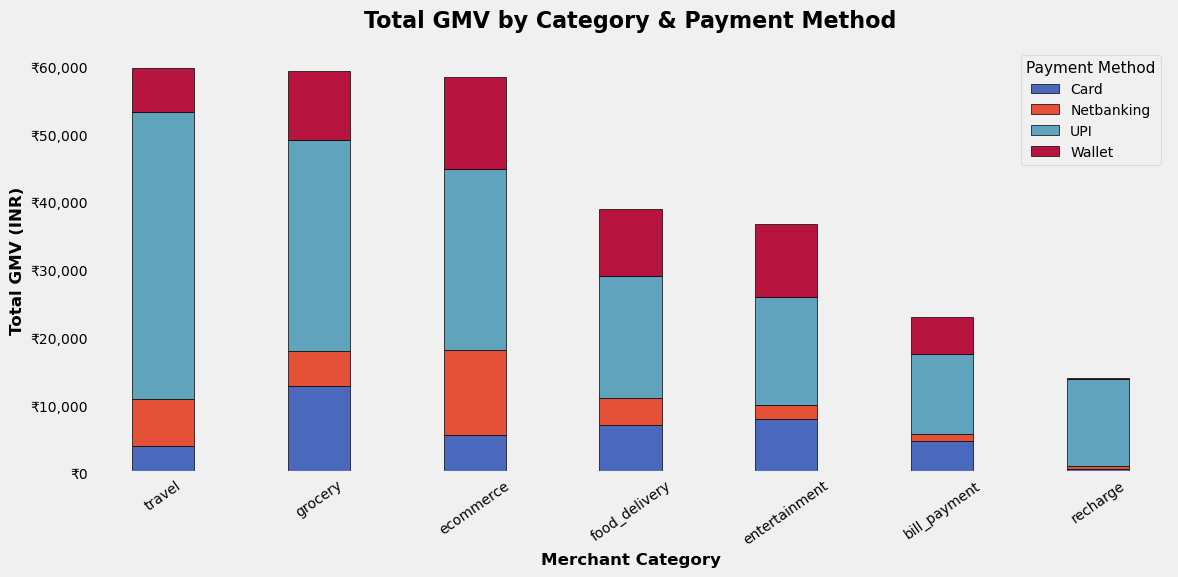

In [6]:
## Breakdown Layer: Stacked Bar Chart of GMV by Category and Payment Method
gmv_stacked=successful_gmv_df.groupby(['category', 'payment_method'])['amount_inr'].sum().unstack(fill_value=0)
gmv_stacked['Total_GMV']=gmv_stacked.sum(axis=1)
gmv_stacked=gmv_stacked.sort_values(by='Total_GMV', ascending=False).drop(columns='Total_GMV')

##Axis titling and visual
plt.style.use('fivethirtyeight')
fig, ax=plt.subplots(figsize=(12, 6))
unified_colors=['#4a69bd', '#e55039', '#60a3bc', '#b71540']
gmv_stacked.plot(kind='bar', stacked=True, ax=ax, edgecolor='black', width=0.4, color=unified_colors)
plt.title("Total GMV by Category & Payment Method", fontweight='bold', fontsize=16, pad=15)
ax.set_xlabel("Merchant Category", fontsize=12, fontweight='bold')
ax.set_ylabel("Total GMV (INR)", fontsize=12, fontweight='bold')
formatter=ticker.StrMethodFormatter('₹{x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

##Axis and Legend optimization
ax.grid(False)
ax.set_ylim(bottom=0)
ax.tick_params(axis='x', labelsize=10, rotation=35)
ax.tick_params(axis='y', labelsize=10)
plt.legend(title="Payment Method", title_fontsize=11, fontsize=10, loc='upper right')

##Chart Processing and image download
plt.tight_layout()

plt.savefig('breakdown_gmv_layer.png', dpi=300)
print("\nBreakdown Layer image successfully saved as 'layer_breakdown_bars.png'")
plt.show()


Risk Details Layer Table image successfully saved as 'layer_risk_details_table.png'


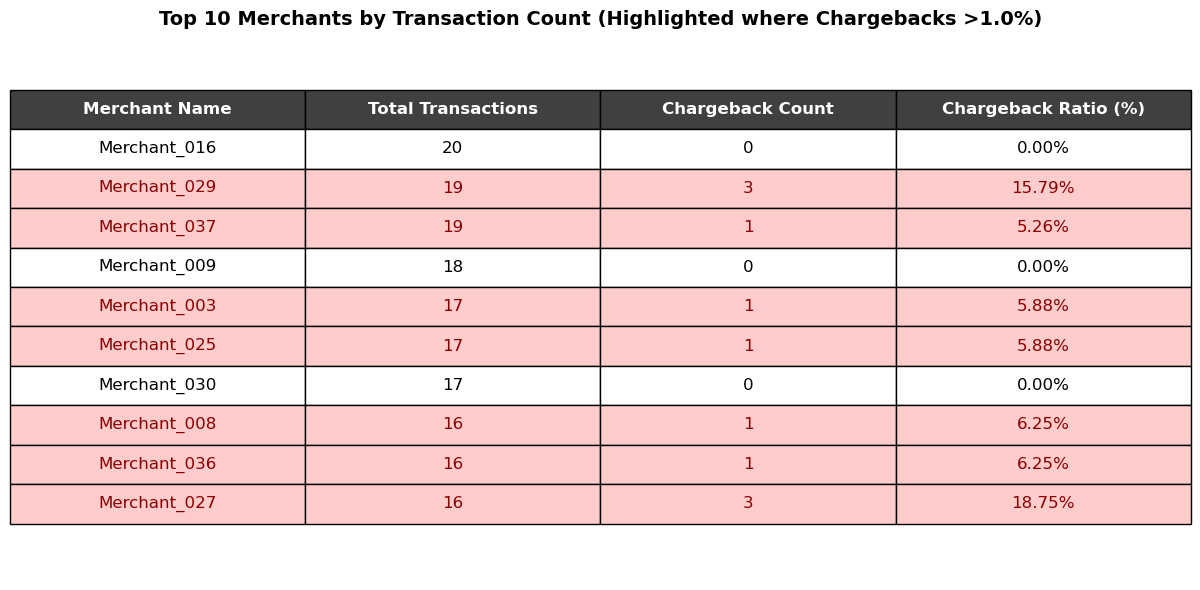

In [7]:
##Details layer top 10 merchants and chargeback ratio
##Merchant data frame
merchant_risk=master_df.groupby(['merchant_id', 'merchant_name']).agg(
    total_txns=('transaction_id', 'count'),
    chargeback_count=('status', lambda x: (x=='chargeback').sum())
).reset_index()
merchant_risk['chargeback_ratio_pct']=(merchant_risk['chargeback_count'] / merchant_risk['total_txns']) * 100

##Merchant data frame rankings
details_table_df = merchant_risk[['merchant_name', 'total_txns', 'chargeback_count', 'chargeback_ratio_pct']]
details_table_df = details_table_df.sort_values(by='total_txns', ascending=False).head(10).reset_index(drop=True)

##Axis titling and visual
plt.style.use('default') 
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
header = ['Merchant Name', 'Total Transactions', 'Chargeback Count', 'Chargeback Ratio (%)']
data_rows = []
ratio_threshold_exceeded = []

for i, row in details_table_df.iterrows():
    formatted_row = [
        row['merchant_name'],
        f"{row['total_txns']:,}",
        row['chargeback_count'],
        f"{row['chargeback_ratio_pct']:.2f}%"
    ]
    data_rows.append(formatted_row)
    ratio_threshold_exceeded.append(row['chargeback_ratio_pct'] > 1.0)
table = ax.table(cellText=data_rows, colLabels=header, loc='center', cellLoc='center')

##Conditional Highlighting Parameters and Table optimization
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.0)
for j, col_header in enumerate(header):
    cell = table.get_celld()[0, j]
    cell.set_facecolor('#404040')
    cell.set_text_props(color='white', fontweight='bold')
for i, exceeded in enumerate(ratio_threshold_exceeded):
    row_idx = i + 1
    for j in range(len(header)):
        cell = table.get_celld()[row_idx, j]
        if exceeded:
            cell.set_facecolor('#ffcccc')
            cell.get_text().set_color('#8b0000')

plt.title("Top 10 Merchants by Transaction Count (Highlighted where Chargebacks >1.0%)", 
          fontweight='bold', fontsize=14, y=1.0)

##Chart Processing and image download
plt.tight_layout()

plt.savefig('details_layer_table.png', dpi=300, bbox_inches='tight')
print("\nRisk Details Layer Table image successfully saved as 'layer_risk_details_table.png'")
plt.show()